In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS

from plotting.cell_state_plotters import plot_cell_state_2d, plot_cell_state_3d

In [2]:
# full_q

full_q_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

# q_filter 

q_filter_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_410.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_553.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))


In [3]:
mode = "normal"

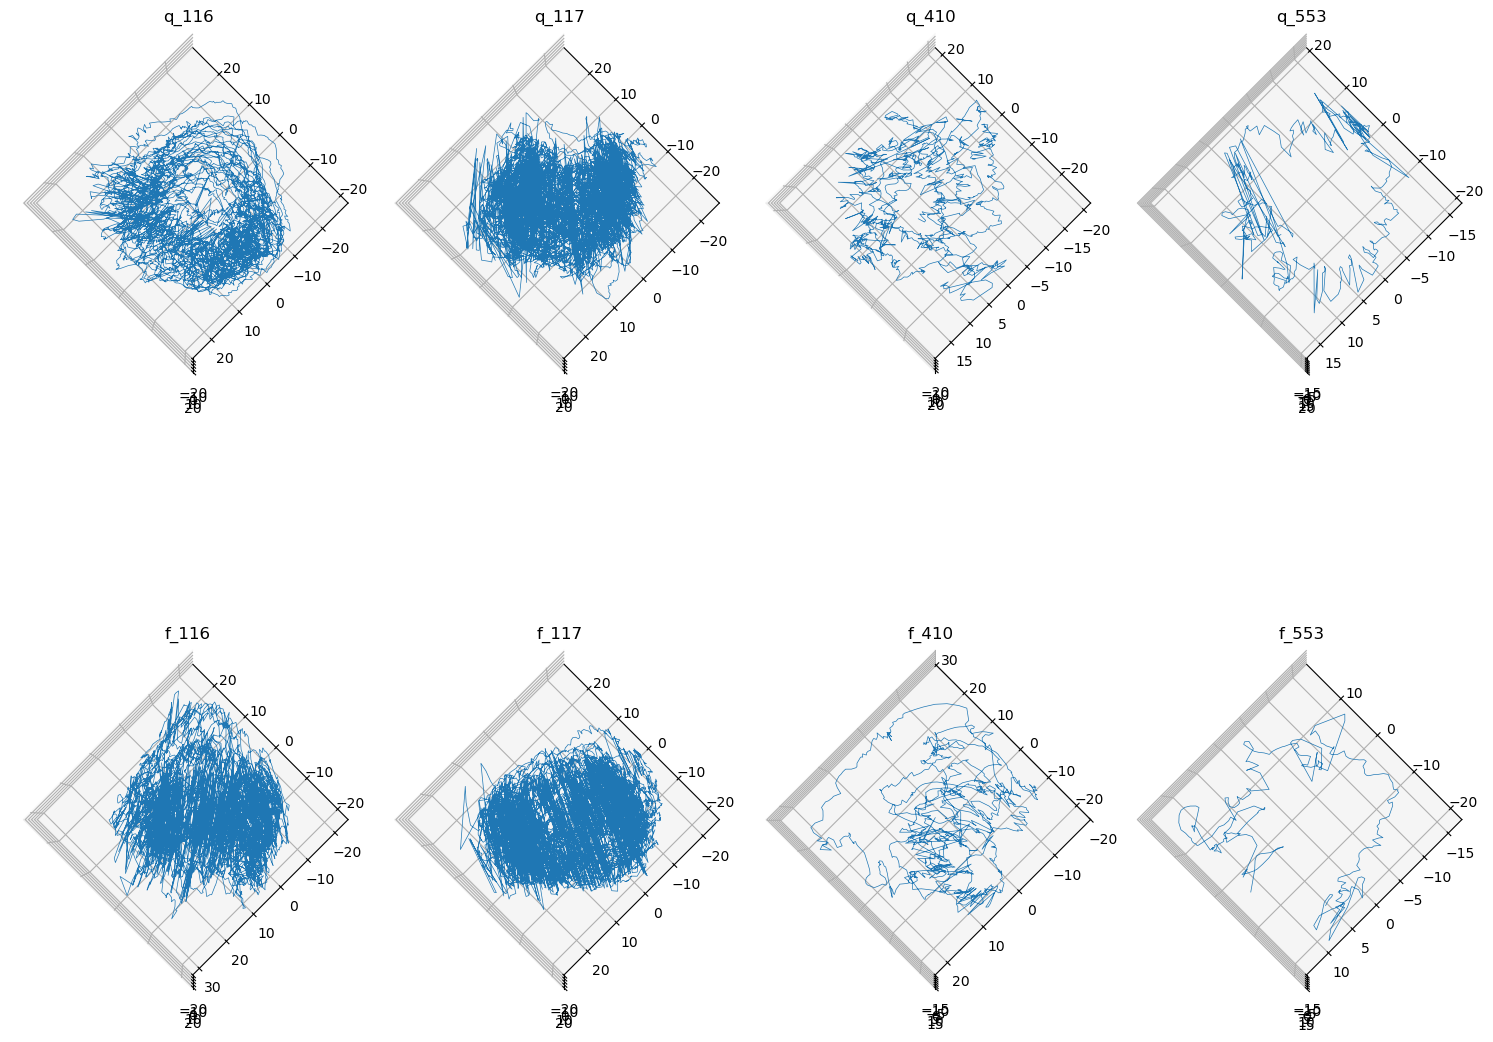

In [4]:
fig, axs = plt.subplots(2,4, figsize=(15,15), subplot_kw={"projection": "3d"})

for ax, array, title in zip(
	axs.ravel(),
	list(map(lambda x: x[mode], full_q_states)) + list(map(lambda x: x[mode], q_filter_states)),
	["q_116", "q_117","q_410", "q_553", "f_116", "f_117", "f_410", "f_553"]):
	
	# Assign every 365 points the same color, to look for seasonal patterns.
	point_colors = np.arange(len(array)) // 365

	plot_cell_state_3d(
		cell_state_array=array,
		ax=ax,
		connect=True,
		ax_view_params={"elev": 90, "azim": 135},
		title=title,
		linewidth=0.5
	)

plt.tight_layout()

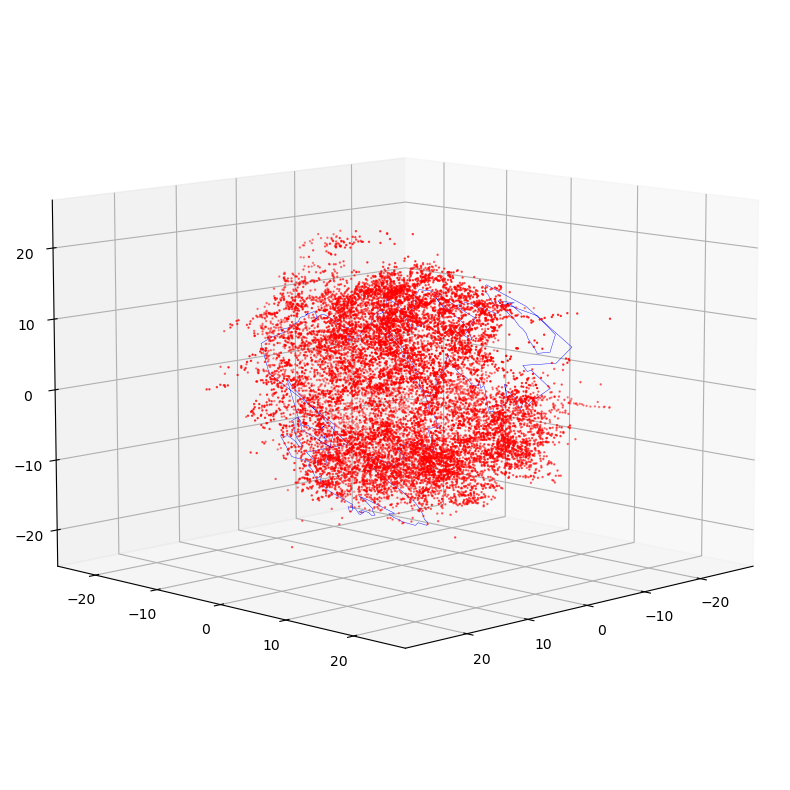

In [5]:
fig, ax = plt.subplots(1,1, figsize=(10,10), subplot_kw={"projection": "3d"})

plot_cell_state_3d(
    cell_state_array=full_q_states[1][mode],
    ax=ax,
    color="red",
    s=0.5
)

plot_cell_state_3d(
    cell_state_array=q_filter_states[1][mode],
    ax=ax,
	connect=True,
    color="blue",
	linewidth=0.3
)

ax.view_init(10, 45)

In [6]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_means_mds.p", "rb") as f: 
    filter_means_mds = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_means_mds.p", "rb") as f: 
    full_means_mds = pickle.load(f)

In [7]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [17]:
show_cluster = False

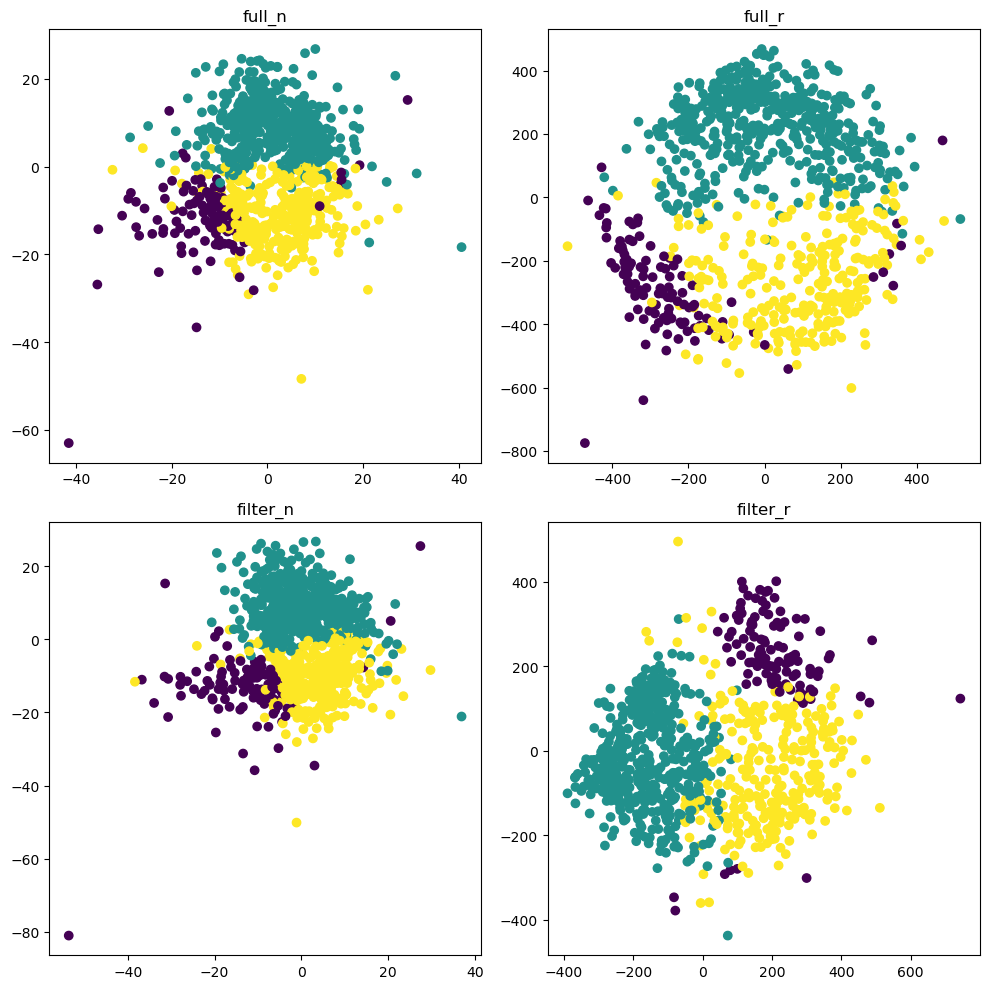

In [20]:
from sklearn.cluster import HDBSCAN, OPTICS

hdbscan = HDBSCAN()
optics = OPTICS(min_cluster_size=30)

fig, axs = plt.subplots(2,2, figsize=(10,10))

for ax, array, title in zip(
    axs.ravel(),
	[full_means_mds["2"][m] for m in ["normal", "raw"]] + [filter_means_mds["2"][m] for m in ["normal", "raw"]],
	["full_n","full_r", "filter_n", "filter_r"]):
	
	if show_cluster:
		cluster = hdbscan.fit_predict(array)
		cluster = optics.fit_predict(array)
		
		print(f"{len(cluster[cluster==-1])} basins could not be assined")

		plot_cell_state_2d(array[cluster!=-1], ax=ax, title=title, c=cluster[cluster !=-1])
	else:
		plot_cell_state_2d(array, ax=ax, title=title, c=strata_ids["0"])

plt.tight_layout()

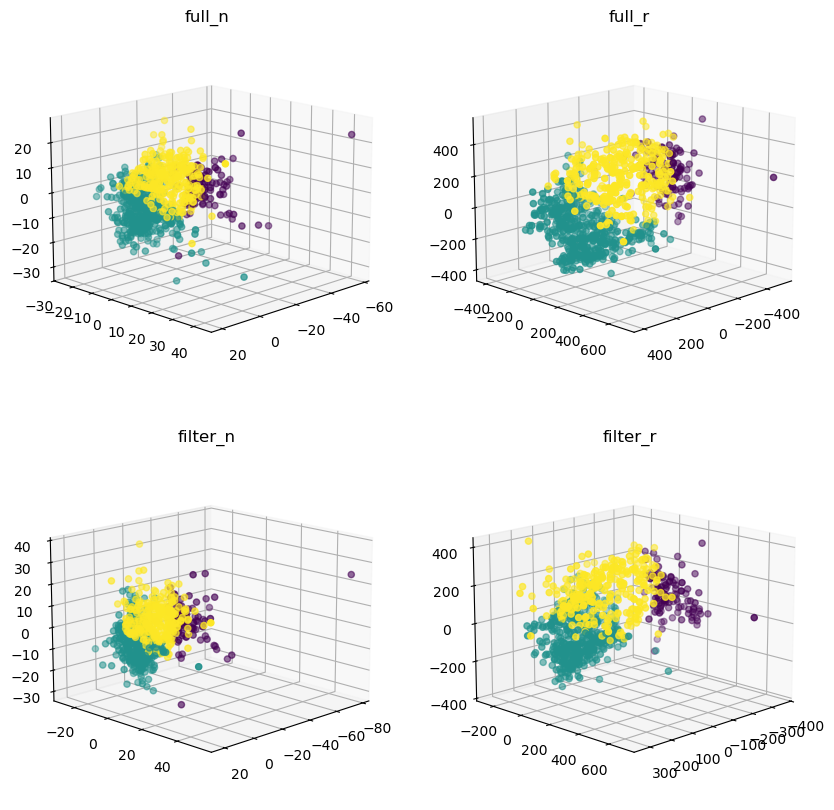

In [18]:
fig, axs = plt.subplots(2,2, figsize=(10,10), subplot_kw={"projection": "3d"})

hdbscan = HDBSCAN(min_cluster_size=20)

for ax, array, title in zip(
    axs.ravel(),
	[full_means_mds["3"][m] for m in ["normal", "raw"]] + [filter_means_mds["3"][m] for m in ["normal", "raw"]],
	["full_n","full_r", "filter_n", "filter_r"]):

	if show_cluster: 
		cluster = hdbscan.fit_predict(array)

		print(f"{len(cluster[cluster==-1])} basins could not be assined")
		
		plot_cell_state_3d(array[cluster!=-1], ax=ax, title=title, ax_view_params={"elev": 15, "azim": 45}, c=cluster[cluster !=-1]) 
	else: 
		plot_cell_state_3d(array, ax=ax, title=title, ax_view_params={"elev": 15, "azim": 45}, c=strata_ids) 


<Axes3D: >

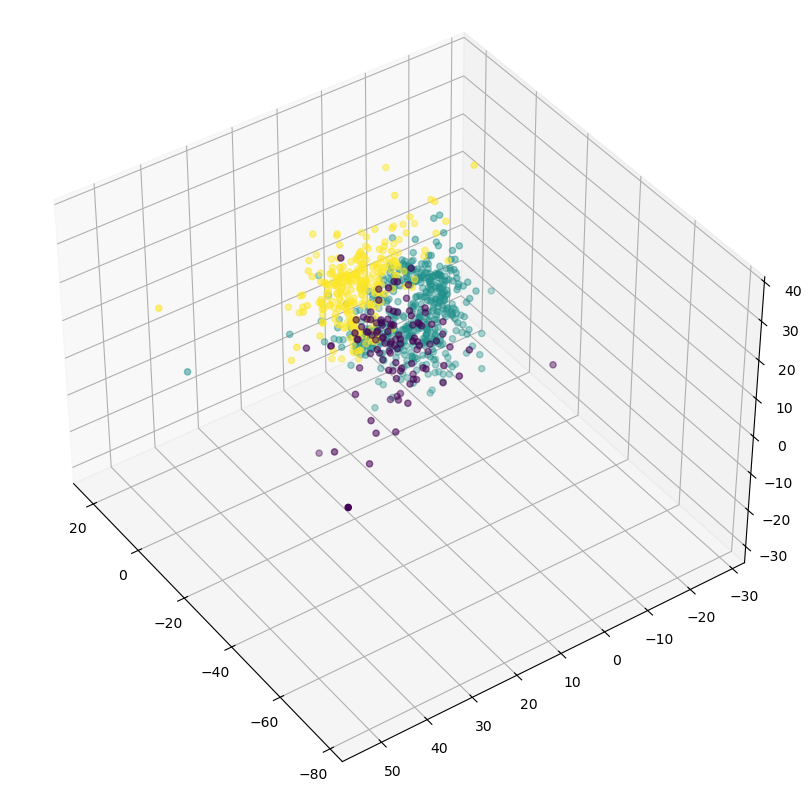

In [10]:

plot_cell_state_3d(filter_means_mds["3"]["normal"], ax_view_params={"elev":40, "azim": 145}, fig_args={"figsize":(10,10)}, c=strata_ids)

In [11]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states.p", "rb") as f: 
    filter_full_states = pickle.load(f)

In [12]:
mean_states = np.vstack([filter_full_states[b]["c_mean"] for b in filter_full_states.keys()])

In [13]:
hdbscan.fit_predict(mean_states)

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  0, -1,  0,  0,
        0, -1, -1, -1,  0, -1,  0, -1, -1,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,
       -1,  0, -1,  0, -1, -1, -1, -1, -1,  0, -1,  1, -1, -1, -1,  0, -1,
        0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
       -1,  1,  1, -1,  1, -1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1, -1,
       -1,  1,  0,  0,  0